In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [11]:
# Load dataset (requires pyarrow for parquet)
df = pd.read_parquet("../data/yellow_tripdata_2025-01.parquet")
print('shape:', df.shape)
print('columns:', df.columns.tolist())

shape: (3475226, 20)
columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


## Initial exploratory analysis

The following cells run descriptive statistics, data quality checks, and list candidate features for predicting hourly pickup demand by zone.

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


Shape: (3475226, 20)
Dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object
Missing values (top 20):
passenger_count          540149
congestion_surcharge     540149
store_and_fwd_flag       540149
RatecodeID               540149
Airp

,count,mean,std,min,25%,50%,75%,max
VendorID,3475226.0,1.785428,0.426328,1.00,2.00,2.00,2.00,7.00
passenger_count,2935077.0,1.297859,0.750750,0.00,1.00,1.00,1.00,9.00
trip_distance,3475226.0,5.855126,564.601600,0.00,0.98,1.67,3.10,276423.57
RatecodeID,2935077.0,2.482535,11.632772,1.00,1.00,1.00,1.00,99.00
PULocationID,3475226.0,165.191576,64.529483,1.00,132.00,162.00,234.00,265.00
DOLocationID,3475226.0,164.125177,69.401686,1.00,113.00,162.00,234.00,265.00
payment_type,3475226.0,1.036623,0.701333,0.00,1.00,1.00,1.00,5.00
fare_amount,3475226.0,17.081803,463.472918,-900.00,8.60,12.11,19.50,863372.12
extra,3475226.0,1.317737,1.861509,-7.50,0.00,0.00,2.50,15.00
mta_tax,3475226.0,0.478099,0.137462,-0.50,0.50,0.50,0.50,10.50


Candidate pickup zone columns: ['tpep_pickup_datetime', 'PULocationID']
tpep_pickup_datetime unique= 1672077
PULocationID unique= 261
--- trip_distance


count    3.475226e+06
mean     5.855126e+00
std      5.646016e+02
min      0.000000e+00
25%      9.800000e-01
50%      1.670000e+00
75%      3.100000e+00
max      2.764236e+05
Name: trip_distance, dtype: float64

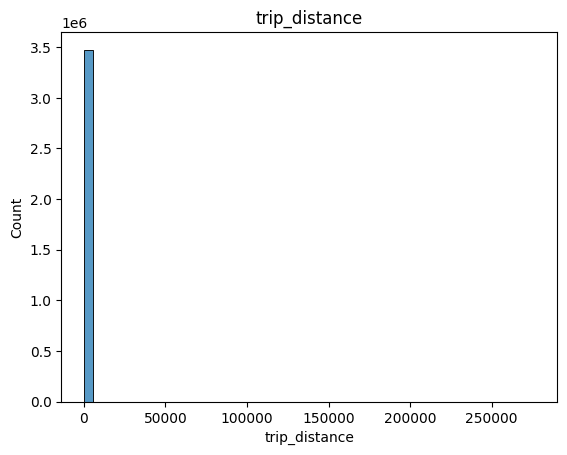

--- passenger_count


count    2.935077e+06
mean     1.297859e+00
std      7.507503e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

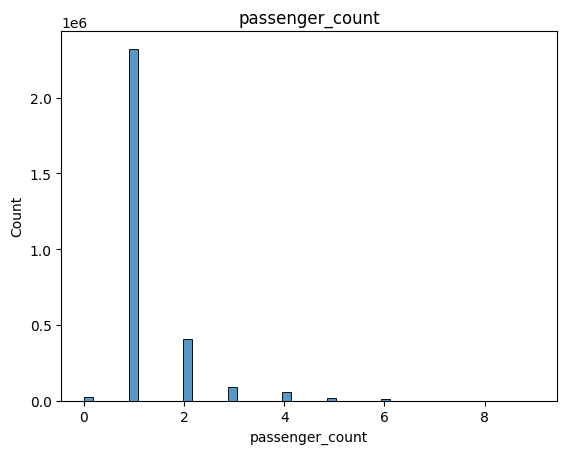

--- fare_amount


count    3.475226e+06
mean     1.708180e+01
std      4.634729e+02
min     -9.000000e+02
25%      8.600000e+00
50%      1.211000e+01
75%      1.950000e+01
max      8.633721e+05
Name: fare_amount, dtype: float64

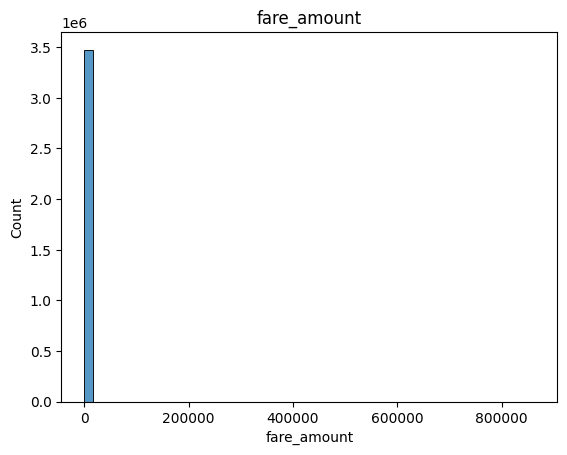

--- total_amount


count    3.475226e+06
mean     2.561129e+01
std      4.636585e+02
min     -9.010000e+02
25%      1.520000e+01
50%      1.995000e+01
75%      2.778000e+01
max      8.633804e+05
Name: total_amount, dtype: float64

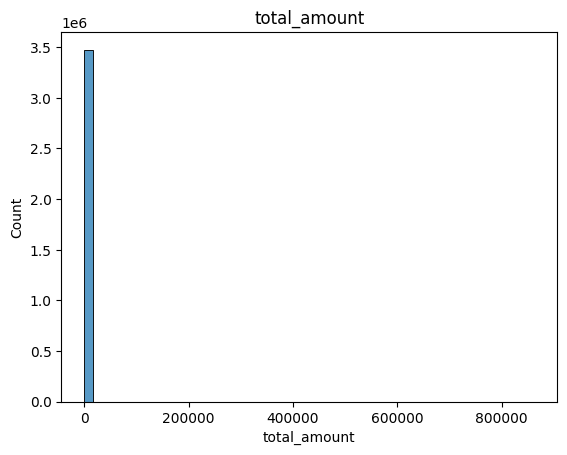

In [12]:
# 1) Descriptive analysis: overview and basic stats
# Quick peek
display(df.head())

# Basic shape and dtypes
print("Shape:", df.shape)
print("Dtypes:")
print(df.dtypes)

# Missing values by column
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values (top 20):")
print(missing.head(20))

# Summary statistics for numeric columns
print("Numeric summary:")
display(df.select_dtypes(include=["number"]).describe().T)

# Top pickup zones (if present)
zone_cols = [c for c in df.columns if 'pu' in c.lower() or 'pickup' in c.lower() or 'pulocation' in c.lower()]
print("Candidate pickup zone columns:", zone_cols)
for c in zone_cols:
    print(c, 'unique=', df[c].nunique() if c in df else 'n/a')

# Quick hist of trip distance and passenger_count (if present)
for c in ['trip_distance','passenger_count','fare_amount','total_amount']:
    if c in df.columns:
        print('---', c)
        display(df[c].describe())
        sns.histplot(df[c].dropna(), bins=50)
        plt.title(c)
        plt.show()

In [13]:
# 2) Data quality checks and detections
issues = {}

# Duplicates
issues['n_duplicates'] = int(df.duplicated().sum())

# Detect datetime-like columns and coerce
dt_candidates = [c for c in df.columns if 'pickup' in c.lower() or 'dropoff' in c.lower() or 'datetime' in c.lower() or 'date' in c.lower()]
issues['datetime_candidates'] = dt_candidates

for c in dt_candidates:
    coerced = pd.to_datetime(df[c], errors='coerce')
    n_coerce = coerced.isna().sum()
    issues[f'na_after_parse_{c}'] = int(n_coerce)
    # attach parsed series for further checks
    df[c+'_parsed'] = coerced

# Range/outlier checks for numeric columns
numeric = df.select_dtypes(include=["number"]).columns.tolist()
issues['numeric_columns'] = numeric[:20]

# Check for non-positive trip_distance or passenger_count
if 'trip_distance' in df.columns:
    issues['trip_distance_nonpos'] = int((df['trip_distance'] <= 0).sum())
if 'passenger_count' in df.columns:
    issues['passenger_count_nonpos'] = int((df['passenger_count'] <= 0).sum())

# Negative monetary values
for money in ['fare_amount','total_amount','tip_amount']:
    if money in df.columns:
        issues[f'neg_{money}'] = int((df[money] < 0).sum())

# Timestamp order check (pickup before dropoff) if both parsed
pick = next((c for c in df.columns if 'pickup' in c.lower() and c.endswith('_parsed')) , None)
drop = next((c for c in df.columns if 'dropoff' in c.lower() and c.endswith('_parsed')) , None)
if pick and drop:
    issues['pickup_after_dropoff'] = int((df[pick] > df[drop]).sum())

# Show issues summary
from pprint import pprint
pprint(issues)

# Display examples of problematic rows for a few checks
if issues.get('n_duplicates',0) > 0:
    display(df[df.duplicated(keep=False)].head())
if 'trip_distance_nonpos' in issues and issues['trip_distance_nonpos']>0:
    display(df[df['trip_distance']<=0].head())
if 'passenger_count_nonpos' in issues and issues['passenger_count_nonpos']>0:
    display(df[df['passenger_count']<=0].head())

{'datetime_candidates': ['tpep_pickup_datetime', 'tpep_dropoff_datetime'],
 'n_duplicates': 0,
 'na_after_parse_tpep_dropoff_datetime': 0,
 'na_after_parse_tpep_pickup_datetime': 0,
 'neg_fare_amount': 144118,
 'neg_tip_amount': 124,
 'neg_total_amount': 63037,
 'numeric_columns': ['VendorID',
                     'passenger_count',
                     'trip_distance',
                     'RatecodeID',
                     'PULocationID',
                     'DOLocationID',
                     'payment_type',
                     'fare_amount',
                     'extra',
                     'mta_tax',
                     'tip_amount',
                     'tolls_amount',
                     'improvement_surcharge',
                     'total_amount',
                     'congestion_surcharge',
                     'Airport_fee',
                     'cbd_congestion_fee'],
 'passenger_count_nonpos': 24656,
 'pickup_after_dropoff': 124,
 'trip_distance_nonpos': 90893}


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,tpep_pickup_datetime_parsed,tpep_dropoff_datetime_parsed
92,1,2025-01-01 00:49:48,2025-01-01 00:49:48,1.0,0.0,1.0,Y,87,264,2,...,0.0,0.00,0.00,0.0,20.06,0.0,0.0,0.0,2025-01-01 00:49:48,2025-01-01 00:49:48
204,2,2025-01-01 00:37:43,2025-01-01 00:37:53,1.0,0.0,5.0,N,148,148,1,...,0.0,2.00,0.00,1.0,17.50,2.5,0.0,0.0,2025-01-01 00:37:43,2025-01-01 00:37:53
358,2,2025-01-01 00:57:08,2025-01-01 00:57:16,3.0,0.0,5.0,N,141,141,1,...,0.0,0.00,0.00,1.0,33.50,2.5,0.0,0.0,2025-01-01 00:57:08,2025-01-01 00:57:16
505,1,2025-01-01 00:27:40,2025-01-01 00:59:30,1.0,0.0,1.0,N,168,76,1,...,0.5,0.00,6.94,1.0,58.94,0.0,0.0,0.0,2025-01-01 00:27:40,2025-01-01 00:59:30
619,2,2025-01-01 00:56:49,2025-01-01 00:56:54,4.0,0.0,5.0,N,164,164,1,...,0.0,7.05,0.00,1.0,30.55,2.5,0.0,0.0,2025-01-01 00:56:49,2025-01-01 00:56:54


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,tpep_pickup_datetime_parsed,tpep_dropoff_datetime_parsed
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.4,1.0,N,170,170,1,...,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0,2025-01-01 00:14:47,2025-01-01 00:16:15
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.6,1.0,N,234,148,1,...,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0,2025-01-01 00:39:27,2025-01-01 00:51:51
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.8,1.0,N,148,170,1,...,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0,2025-01-01 00:53:43,2025-01-01 01:13:23
94,1,2025-01-01 00:11:27,2025-01-01 00:16:58,0.0,0.7,1.0,N,144,211,1,...,0.5,0.00,0.0,1.0,12.20,2.5,0.0,0.0,2025-01-01 00:11:27,2025-01-01 00:16:58
95,1,2025-01-01 00:19:30,2025-01-01 00:27:25,0.0,1.0,1.0,N,211,158,1,...,0.5,2.85,0.0,1.0,17.15,2.5,0.0,0.0,2025-01-01 00:19:30,2025-01-01 00:27:25


## 2) Data quality issues — what to look for and how to detect

- **Missing values:** detect with `df.isnull().sum()`; critical for datetime or zone columns.
- **Duplicates:** detect with `df.duplicated()`; remove exact duplicates or aggregate if intentional.
- **Invalid timestamps:** coerce with `pd.to_datetime(..., errors='coerce')` and check coerced NA counts and order (pickup vs dropoff).
- **Outliers / impossible values:** check numeric ranges (e.g., `trip_distance <= 0`, negative fares, extremely large distances or durations).
- **Schema inconsistencies:** unexpected zone IDs, mixed data types; use `df.dtypes` and `df['zone_col'].unique()` to inspect.
- **Temporal gaps / timezone issues:** plot time series of counts to reveal gaps or shifts.

Mitigation approaches: imputation, filtering (remove erroneous rows), feature engineering (cap/transform outliers), and careful timezone-aware parsing.

## 3) Which columns are useful for predicting hourly demand by pickup zone?

Useful columns and why:

- **Pickup datetime (e.g., `pickup_datetime`):** primary signal to derive hour-of-day, day-of-week, holidays, and seasonal patterns.
- **Pickup zone / `PULocationID` / pickup_zone:** the spatial unit for demand aggregation and the modeling target (pickups per zone).
- **Passenger count:** can reflect group sizes and may correlate with demand intensity.
- **Trip distance / duration:** helps distinguish short local trips vs long trips that remove vehicles from service.
- **Fare / total amount:** proxy for trip value and may correlate with demand patterns (e.g., surge pricing).
- **Vendor / taxi type:** different fleets may serve different demand patterns.
- **Store_and_fwd_flag / rate_code:** indicators of special trip handling or service type.

Additional external features to join (recommended): weather, public events, transit outages, and nearby POI/land-use.

Derived features to build:
- Lagged counts per zone (1h, 24h), rolling means, and differences.
- Time-based features: hour, weekday, is_weekend, is_holiday.
- Spatial context: neighboring-zone demand, distance to central business districts, and density metrics.